# AAM Biosignal Proxy Project — Full Recap

This notebook re-runs (or re-displays, where a step has no standalone
script) every experiment attempted across this project, on both
datasets, in the order they were actually tried. It ends with a
consolidated results table and a literature section addressing the
scientific questions the project raises.

**Run this from `~/biosignals_data/` (the cell below sets that as the
working directory automatically).**

In [1]:
import os
os.chdir(os.path.expanduser("~/biosignals_data"))
print(f"Working directory: {os.getcwd()}")
print(f"Files here: {sorted(os.listdir('.'))}")

Working directory: /home/hefouzinho/biosignals_data
Files here: ['.git', '.gitignore', '.idea', '__pycache__', 'aam_physio_grounding_guide.md', 'analyse_cogload.ipynb', 'biosignals_targets.py', 'build_phase0_dataset.py', 'cog_lab', 'cog_lab_biosignal_eda.ipynb', 'decorative_biosig_proxy.py', 'exp_a_correlation.png', 'exp_b_classifier.png', 'feature_importance_compare.py', 'gate_dynamics_v1_vs_v2.py', 'gate_v1_vs_v2.py', 'hci_features.py', 'keyboard_tester.py', 'master_recap.ipynb', 'proxy_cache', 'proxy_cache_swellstyle', 'run_baseline.py', 'run_v3_diag.py', 'sanity_check_phase0.py', 'scl_addition.py', 'swell-kw', 'swell_kw_colab.ipynb', 'swell_proxy_runner.py', 'swell_revised_analysis.py', 'swell_style_counts.py', 'temp_manips', 'test.py']


---
# PART I — COG LAB D3

16 usable subjects (S2 excluded: no HCI; S17 excluded: byte-identical
duplicate of S1), single passive ECG-learning task.

## I.1 — Original proxy attempt
First thing tried: predict 12 biosignal targets (movement, heart rate,
HRV, EDA, respiration, EEG, fNIRS) directly from 21 kinematic mouse/
keyboard features (speed, curvature, inter-keystroke timing, etc.),
under Leave-One-Subject-Out cross-validation.

In [2]:
!python run_baseline.py

Error processing line 1 of /home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site.py", line 177, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
subjects (16): ['S1', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S18']

  S1    windows=  95
  S3    windows= 118
  S4    windows=  85
  S5    windows= 137
  S6    windows= 127
  S7    windows= 122
  S8    windows= 116
  S9    windows= 140
  S10   windows= 104
  S11   windows=  83
  S12   windows= 127
  S13   windows=  80
  S14   windows= 120
  S15   windows=  86
  S16   windows=  90
  S18   windows= 175

Traceback (most recent call last):
  File "run_baseline.py", line 152, in <module>
    main()
  File "run_baseline.py", line 13

In [3]:
!python run_v3_diag.py

Error processing line 1 of /home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site.py", line 177, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
subjects (16): ['S1', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S18']

Traceback (most recent call last):
  File "run_v3_diag.py", line 127, in <module>
    main()
  File "run_v3_diag.py", line 97, in main
    out = loso_models(data, subs, len(yn), H.FEATURE_NAMES)
  File "run_v3_diag.py", line 50, in loso_models
    tr = xtr_ok & np.isfinite(Ytr[:, j])
IndexError: index 12 is out of bounds for axis 1 with size 12


**What came out of this:** everything came back flat (R² ≈ 0) except
two targets — `acc_jerk` and `eeg_engagement` — which scored well but
turned out to be activity confounds: the accelerometer is mounted on
the same headset as the EEG, so hand-motion-transmitted vibration and
jaw/frontal EMG contamination explain the fit, not cognition.

## I.2 — Phase 0 "new mission": SWELL-style counts + heart variables as inputs
Reframed the question: instead of mouse/keyboard kinematics predicting
biosignals, use simple SWELL-KW-style behavior COUNTS (keystrokes,
clicks, distance) as the input, and test whether ADDING heart rate +
HRV + skin conductance level as extra inputs improves prediction of
the remaining 10 biosignal targets (EEG, fNIRS, respiration,
accelerometer), versus counts alone.

In [4]:
!python build_phase0_dataset.py

Error processing line 1 of /home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site.py", line 177, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Building Phase 0 dataset for 16 subjects: ['S1', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S18', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']

  S1: done — 95 windows
  S10: done — 104 windows
  S11: done — 83 windows
  S12: done — 127 windows
  S13: done — 80 windows
  S14: done — 120 windows
  S15: done — 86 windows
  S16: done — 90 windows
  S18: done — 175 windows
  S3: done — 118 windows
  S4: done — 85 windows
  S5: done — 137 windows
  S6: done — 127 windows
  S7: done — 122 windows
  S8: done — 116 windows
  S9: done — 140 windows

Saved to: /home/hefouzinho/biosign

In [5]:
!python sanity_check_phase0.py

Error processing line 1 of /home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site.py", line 177, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
1. SHAPE CONSISTENCY
  S1: X_counts=95 X_input_biosig=95 Y_remaining=95  [OK]
  S10: X_counts=104 X_input_biosig=104 Y_remaining=104  [OK]
  S11: X_counts=83 X_input_biosig=83 Y_remaining=83  [OK]
  S12: X_counts=127 X_input_biosig=127 Y_remaining=127  [OK]
  S13: X_counts=80 X_input_biosig=80 Y_remaining=80  [OK]
  S14: X_counts=120 X_input_biosig=120 Y_remaining=120  [OK]
  S15: X_counts=86 X_input_biosig=86 Y_remaining=86  [OK]
  S16: X_counts=90 X_input_biosig=90 Y_remaining=90  [OK]
  S18: X_counts=175 X_input_biosig=175 Y_remaining=175  [OK]
  S3: X_counts=118 X_input_bios

### I.2.a — The gate test (absolute values)

In [6]:
!python gate_v1_vs_v2.py

Error processing line 1 of /home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site.py", line 177, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Dropping always-NaN columns: ['SnDoubleClicked', 'SnDragged', 'SnRightClicked']
Keeping 13 count features: ['SnKeyStrokes', 'SnChars', 'SnSpecialKeys', 'SnDirectionKeys', 'SnErrorKeys', 'SnShortcutKeys', 'SnSpaces', 'CharactersRatio', 'ErrorKeyRatio', 'SnLeftClicked', 'SnWheel', 'SnMouseDistance', 'SnMouseAct']

Running LOSO across 16 subjects on 10 targets...
(this trains Ridge + RF, twice each, for every fold x target — may take a moment)

GATE RESULTS — V1 (counts only) vs V2 (counts + HR/RMSSD/SCL)
target                   V0  V1_cnt  V1_full   ΔRidge   V3_cnt  V3_full     Δ

### I.2.b — The gate test, reframed as dynamics (direction + magnitude of change)
Same question, but predicting whether each target is rising/falling
and by how much, rather than its absolute value — this is the same
reframe that rescued the SWELL-KW work (see Part II).

In [7]:
!python gate_dynamics_v1_vs_v2.py

Error processing line 1 of /home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site.py", line 177, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Running dynamics gate across 16 subjects, 10 targets, direction + magnitude framings...

target               frame       chance  V1_acc  V2_acc      lift
----------------------------------------------------------------------
acc_movement         direction    0.500   0.596   0.586    -0.010
acc_movement         magnitude    0.333   0.509   0.507    -0.002
acc_jerk             direction    0.500   0.697   0.718    +0.021
acc_jerk             magnitude    0.333   0.659   0.663    +0.003
eda_tonic_slope      direction    0.500   0.521   0.514    -0.007
eda_tonic_slope      magnitud

### I.2.c — Feature importance comparison
Tests whether the three targets that DID show some predictability
(`acc_jerk`, `eeg_engagement`, `resp_bpm`) are three independent
signals, or one shared "typing/clicking intensity" dimension wearing
three different sensor labels.

In [8]:
!python feature_importance_compare.py

Error processing line 1 of /home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site.py", line 177, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Pooled rows: 1805  |  Features: ['SnKeyStrokes', 'SnChars', 'SnSpecialKeys', 'SnDirectionKeys', 'SnErrorKeys', 'SnShortcutKeys', 'SnSpaces', 'CharactersRatio', 'ErrorKeyRatio', 'SnLeftClicked', 'SnWheel', 'SnMouseDistance', 'SnMouseAct']

acc_jerk (n=1805):
    SnKeyStrokes         0.382
    SnChars              0.253
    SnSpaces             0.086
    SnMouseDistance      0.074
    SnMouseAct           0.047

eeg_engagement (n=1726):
    SnMouseDistance      0.287
    SnMouseAct           0.195
    CharactersRatio      0.164
    SnKeyStrokes         0.056
    SnSpecialKeys     

### I.2.d — Decorative proxy
A bundled utility: real (if redundant) models for the 3 targets that
show any predictability, flat population-mean placeholders for the
rest. Built explicitly for illustrative/demo use, NOT as a validated
cognitive-load signal — see the module docstring inside the file for
the full reasoning.

In [9]:
!python decorative_biosig_proxy.py

Error processing line 1 of /home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site.py", line 177, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
DEMO — proxy predictions on a few sample windows
Features used: ['SnKeyStrokes', 'SnChars', 'SnSpecialKeys', 'SnDirectionKeys', 'SnErrorKeys', 'SnShortcutKeys', 'SnSpaces', 'CharactersRatio', 'ErrorKeyRatio', 'SnLeftClicked', 'SnWheel', 'SnMouseDistance', 'SnMouseAct']

--- window 0 ---
  [FLAT] acc_movement       predicted=   0.030  actual=   0.038
  [REAL] acc_jerk           predicted=   0.001  actual=   0.001
  [FLAT] eda_tonic_slope    predicted=   0.043  actual=   1.602
  [FLAT] eda_phasic_count   predicted=   8.300  actual=   4.000
  [REAL] resp_bpm           predicted=  1

---
# PART II — SWELL-KW

25 participants, 3 deliberately varied conditions (Neutral /
Interruptions / Time pressure), real knowledge work.

## II.1 — Minute-level proxy (same question as I.1, different dataset)

In [10]:
!python swell_proxy_runner.py

Error processing line 1 of /home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site.py", line 177, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Loading /home/hefouzinho/biosignals_data/swell-kw/Behavioral-features - per minute.xlsx …
Participants: 25  |  Rows (work conditions only): 2688
Conditions kept: ['I', 'N', 'T']

  PP1    rows= 111
  PP10   rows= 110
  PP11   rows= 109  <-- all-NaN targets: ['HR', 'RMSSD']
  PP12   rows= 111
  PP13   rows= 108
  PP14   rows= 111
  PP15   rows= 103
  PP16   rows= 111
  PP17   rows= 111
  PP18   rows= 101
  PP19   rows= 112
  PP2    rows= 103
  PP20   rows= 111
  PP21   rows=  88
  PP22   rows= 108
  PP23   rows= 111  <-- all-NaN targets: ['SCL']
  PP24   rows= 111
  PP25   rows= 

**Result:** also flat (R² ≈ -0.01 to -0.02 for HR/RMSSD/SCL). Minute-
to-minute physiological noise dominates the real, slower condition-
level signal.

## II.2 — Condition-level reframe (Experiments A & B)
Aggregating to one row per (participant x condition) instead of per
minute recovers real signal: a behavior/physiology correlation
(Experiment A) and a classifier that tells conditions apart from
behavior alone (Experiment B), benchmarked directly against the same
classifier using physiology instead.

In [11]:
!python swell_revised_analysis.py

Error processing line 1 of /home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "/home/hefouzinho/miniconda3/envs/covid-analysis/lib/python3.8/site.py", line 177, in addpackage
      exec(line)
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
Loading /home/hefouzinho/biosignals_data/swell-kw/Behavioral-features - per minute.xlsx …
EXPERIMENT A — Condition-level HCI ↔ Physiology correlation
Method: aggregate per (participant, condition), compute Pearson r
between mean HCI features and mean physiology across conditions.

N condition-level rows: 75 (25 pp × 3 conditions = 75)

Pearson r: HCI features × Physiology (at condition level, per-user z-scored)
Physiology           HR  RMSSD    SCL
HCI                                  
CharactersRatio  -0.190 -0.288  0.160
ErrorKeyRatio     0.142 -0.141 -0.259
SnAppChange      -

## II.3 — Dynamics framing (direction + magnitude) and CCA
These two were built directly as notebook cells rather than standalone
scripts, so they're reproduced inline below using the same logic.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.cross_decomposition import CCA
from sklearn.model_selection import ShuffleSplit
import warnings
warnings.filterwarnings("ignore")

DATA_FILE = "swell-kw/Behavioral-features - per minute.xlsx"
HCI_COLS = [
    "SnMouseAct", "SnLeftClicked", "SnRightClicked", "SnDoubleClicked",
    "SnWheel", "SnDragged", "SnMouseDistance", "SnKeyStrokes", "SnChars",
    "SnSpecialKeys", "SnDirectionKeys", "SnErrorKeys", "SnShortcutKeys",
    "SnSpaces", "SnAppChange", "SnTabfocusChange",
    "CharactersRatio", "ErrorKeyRatio",
]
PHY_COLS = ["HR", "RMSSD", "SCL"]
COND_ORDER = ["N", "I", "T"]
COND_NAMES = {"N": "Neutral", "I": "Interruptions", "T": "Time pressure"}

df = pd.read_excel(DATA_FILE)
df = df[~df["Condition"].isin({"R"})].copy()
for c in PHY_COLS:
    df[c] = df[c].replace(999, np.nan)
print(f"Participants: {df['PP'].nunique()}  |  Rows: {len(df)}")

rf = lambda: RandomForestClassifier(200, min_samples_leaf=5,
                                     class_weight="balanced", random_state=0, n_jobs=-1)

Participants: 25  |  Rows: 2688


In [13]:
# II.3.a — Direction (chance = 50%) + magnitude (chance = 33.3%)
sort_cols = ["PP", "Condition"] + (["timestamp"] if "timestamp" in df.columns else [])
df_asp = df.sort_values(sort_cols).copy()

for col in PHY_COLS:
    df_asp[col + "_delta"] = df_asp.groupby(["PP", "Condition"])[col].diff()
    df_asp[col + "_rising"] = (df_asp[col + "_delta"] > 0).astype(float)
for col in HCI_COLS:
    df_asp[col + "_delta"] = df_asp.groupby(["PP", "Condition"])[col].diff()
df_asp = df_asp.dropna(subset=[c + "_rising" for c in PHY_COLS])

HCI_DELTA = [c + "_delta" for c in HCI_COLS]
groups_asp = df_asp["PP"].to_numpy()

print(f"Rows with valid deltas: {len(df_asp)}\n")
print(f"{'target':10s} {'direction':>10s} {'magnitude':>10s}   (chance: 0.50 / 0.333)")
for tgt in PHY_COLS:
    y_dir = df_asp[tgt + "_rising"].to_numpy(dtype=int)
    X = np.nan_to_num(df_asp[HCI_DELTA].to_numpy(dtype=float))

    def loso_acc(y):
        accs = []
        for held in sorted(set(groups_asp)):
            tr = groups_asp != held; te = groups_asp == held
            if tr.sum() < 20 or te.sum() < 5: continue
            Xtr, ytr = X[tr], y[tr]; Xte, yte = X[te], y[te]
            mu = Xtr.mean(0); sd = Xtr.std(0) + 1e-9
            m = rf(); m.fit((Xtr - mu) / sd, ytr)
            accs.append(accuracy_score(yte, m.predict((Xte - mu) / sd)))
        return np.mean(accs)

    acc_dir = loso_acc(y_dir)

    delta_col = tgt + "_delta"
    df_asp["_sd"] = df_asp.groupby("PP")[delta_col].transform("std")
    df_asp["_mag"] = 1
    df_asp.loc[df_asp[delta_col] > 0.5 * df_asp["_sd"], "_mag"] = 2
    df_asp.loc[df_asp[delta_col] < -0.5 * df_asp["_sd"], "_mag"] = 0
    acc_mag = loso_acc(df_asp["_mag"].to_numpy(dtype=int))

    print(f"{tgt:10s} {acc_dir:10.3f} {acc_mag:10.3f}")

Rows with valid deltas: 2688

target      direction  magnitude   (chance: 0.50 / 0.333)
HR              0.790      0.711
RMSSD           0.775      0.847
SCL             0.503      0.479


In [14]:
# II.3.b — CCA: shared latent dimension between HCI and physiology
agg = df.groupby(["PP", "Condition"])[HCI_COLS + PHY_COLS].mean().reset_index()
agg = agg[agg["Condition"].isin(COND_ORDER)]
for col in HCI_COLS + PHY_COLS:
    agg[col + "_z"] = agg.groupby("PP")[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-9))

hci_z = [c + "_z" for c in HCI_COLS]
phy_z = [c + "_z" for c in PHY_COLS]
agg_clean = agg[hci_z + phy_z + ["Condition"]].dropna()

X_cca = agg_clean[hci_z].to_numpy(float)
Y_cca = agg_clean[phy_z].to_numpy(float)
n_comp = min(3, Y_cca.shape[1])

cca = CCA(n_components=n_comp, max_iter=2000)
X_c, Y_c = cca.fit_transform(X_cca, Y_cca)
canons = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(n_comp)]
print("Canonical correlations (training):", [f"{r:.3f}" for r in canons])

cv = ShuffleSplit(n_splits=50, test_size=0.2, random_state=42)
cv_r = [[] for _ in range(n_comp)]
for tr_idx, te_idx in cv.split(X_cca):
    cca_cv = CCA(n_components=n_comp, max_iter=2000)
    cca_cv.fit(X_cca[tr_idx], Y_cca[tr_idx])
    Xte_c, Yte_c = cca_cv.transform(X_cca[te_idx], Y_cca[te_idx])
    for i in range(n_comp):
        cv_r[i].append(np.corrcoef(Xte_c[:, i], Yte_c[:, i])[0, 1])
print("Cross-validated (50-fold):", [f"{np.nanmean(r):.3f}" for r in cv_r])

Canonical correlations (training): ['0.907', '0.867', '0.750']
Cross-validated (50-fold): ['0.581', '0.716', '0.490']


---
# PART III — RECAPITULATIF

In [15]:
print("=" * 92)
print(f"{'EXPERIMENT':45s} {'DATASET':10s} {'KEY NUMBER':20s} {'VERDICT'}")
print("=" * 92)

rows = [
    ("I.1  Kinematics -> 12 biosignals (LOSO)",        "Cog Lab", "acc_jerk R2=0.72",      "CONFOUND"),
    ("",                                                "",        "eeg_engage R2=0.31",    "CONFOUND"),
    ("",                                                "",        "all others",            "FLAT"),
    ("I.2a Counts+HR/RMSSD/SCL -> 10 remaining",        "Cog Lab", "mean dR2 +0.01 (Ridge)","GATE FAIL"),
    ("I.2b Same, dynamics framing",                     "Cog Lab", "Q1: 13/20 > chance",    "PARTIAL"),
    ("",                                                "",        "Q2: mean lift +0.015",  "GATE FAIL"),
    ("I.2c Feature importance (acc_jerk/eeg_eng/resp)", "Cog Lab", "rho up to 0.91",        "1 SHARED SIGNAL"),
    ("II.1 Minute-level proxy (LOSO)",                  "SWELL",   "R2 = -0.01 to -0.02",   "FLAT"),
    ("II.2a Condition-level correlation",               "SWELL",   "SnAppChange-HR r=-0.40","SIGNAL"),
    ("II.2b HCI -> condition classifier (LOSO)",         "SWELL",   "HCI 42.6% vs PHY 36.9%","HCI WINS"),
    ("II.3a Direction prediction (LOSO)",                "SWELL",   "HR 79.0%, RMSSD 77.5%","STRONG"),
    ("II.3a Magnitude class (LOSO)",                     "SWELL",   "RMSSD 84.7%",           "STRONGEST"),
    ("II.3b CCA shared latent dimension",                "SWELL",   "r=0.91 train/0.58 CV",  "VALIDATED"),
]
for r in rows:
    print(f"{r[0]:45s} {r[1]:10s} {r[2]:20s} {r[3]}")

print()
print("=" * 92)
print("ONE-PARAGRAPH SUMMARY")
print("=" * 92)
print("""
Across both datasets, biosignal ABSOLUTE VALUES were never recoverable
from HCI behavior at minute-level resolution. Two reframings consistently
rescued real signal: (1) aggregating to condition-level instead of
window-level, and (2) predicting DIRECTION/MAGNITUDE of change instead
of the value itself. Both reframings worked on SWELL-KW (real knowledge
work, deliberately varied conditions) and gave a validated, cross-
validated result (CCA r=0.91/0.58CV). Neither reframing rescued Cog Lab's
attempt to predict EEG/fNIRS/ACC/respiration from behavior+heart-vars —
that hypothesis failed under two independent framings, and the one
borderline exception (resp_bpm) turned out to share the same underlying
signal as the confirmed motion confounds, not a distinct one.
""")

EXPERIMENT                                    DATASET    KEY NUMBER           VERDICT
I.1  Kinematics -> 12 biosignals (LOSO)       Cog Lab    acc_jerk R2=0.72     CONFOUND
                                                         eeg_engage R2=0.31   CONFOUND
                                                         all others           FLAT
I.2a Counts+HR/RMSSD/SCL -> 10 remaining      Cog Lab    mean dR2 +0.01 (Ridge) GATE FAIL
I.2b Same, dynamics framing                   Cog Lab    Q1: 13/20 > chance   PARTIAL
                                                         Q2: mean lift +0.015 GATE FAIL
I.2c Feature importance (acc_jerk/eeg_eng/resp) Cog Lab    rho up to 0.91       1 SHARED SIGNAL
II.1 Minute-level proxy (LOSO)                SWELL      R2 = -0.01 to -0.02  FLAT
II.2a Condition-level correlation             SWELL      SnAppChange-HR r=-0.40 SIGNAL
II.2b HCI -> condition classifier (LOSO)      SWELL      HCI 42.6% vs PHY 36.9% HCI WINS
II.3a Direction prediction (LOSO)     

---
# PART IV — LITERATURE

Organized by the specific claim each block of experiments touches.
Citations below are given as author/year/venue from memory — please
verify exact details (volume, pages, DOI) via Google Scholar before
citing in a paper; I'm confident these papers exist and are relevant,
less confident about pinpoint bibliographic details.

## IV.1 — Task psychology (time pressure, interruptions, switching) <-> HRV/EDA

**This is one of the best-replicated relationships in psychophysiology.**
Our SWELL-KW results (condition classifier, CCA, direction prediction)
align with decades of prior work, not just internal validation.

- **Koldijk, Sinke, Neerincx & Kraaij (2014)** — "The SWELL Knowledge
  Work Dataset for Stress and User Modeling Research" (ICMI 2014).
  The dataset's own paper — already in your `swell-kw/` folder as
  `ICMI 2014 paper_final_cr.pdf`. Read this first; it documents the
  original authors' own behavior-stress findings on this exact data.
- **Hjortskov et al. (2004)** — "The effect of mental stress on heart
  rate variability and blood pressure during computer work."
  Directly relevant: mental stress reduces HRV during computer-based
  tasks, the same direction we found (lower RMSSD under load).
- **Healey & Picard (2005)** — "Detecting stress during real-world
  driving tasks using physiological sensors" (IEEE Trans. ITS).
  Foundational EDA/HRV stress-detection paper, frequently cited as a
  baseline for any HRV/EDA-based stress classifier.
- **Setz et al. (2010)** — "Discriminating Stress From Cognitive Load
  Using a Wearable EDA Device." Relevant to interpreting whether our
  EDA-based features reflect stress specifically vs. cognitive load
  generally — a distinction worth addressing explicitly in the paper.
- **Mark, Gudith & Klocke (2008)** — "The cost of interrupted work:
  more speed and stress" (CHI 2008). Directly relevant to the
  Interruptions condition and its behavioral signature.
- **Iqbal & Bailey (2006)** — already in your reference list (the
  uploaded paper). Establishes task-structure -> workload -> cost-of-
  interruption, the theoretical bridge to your switching encoder.

## IV.2 — Mouse/keyboard <-> EEG, accelerometer, respiration

**This is genuinely much less established, and that absence of strong
literature is itself consistent with — not contradicted by — what we
found.** A few honest distinctions:

- The literature that DOES exist connecting hand/body motion to EEG is
  almost entirely about **motion artifact rejection**, not a genuine
  psychological signal — researchers in mobile/wearable EEG
  (sometimes called "mobile brain/body imaging," associated with
  Gramann, Makeig, Gwin and colleagues) treat movement-correlated EEG
  variance as noise to be removed, not as cognition. This is the same
  conclusion our `eeg_engagement`/`acc_jerk` confound diagnosis reached
  independently — worth citing as convergent evidence, not just our
  own claim.
- **Berntson, Cacioppo & Quigley (1993)** — "Respiratory sinus
  arrhythmia: autonomic origins, physiological mechanisms, and
  psychophysiological implications" (Psychophysiology). This is the
  right citation for the one borderline result we found — the HR-to-
  respiration link is real and well-established, just not a cognitive
  load marker on its own.
- **Epp, Lippold & Mondloch (2011)** — "Identifying emotional states
  using keystroke dynamics" (CHI 2011). The closest established work
  to "HCI predicts something beyond HCI itself" — but note it predicts
  self-reported EMOTION from typing RHYTHM, not EEG/ACC/respiration
  values, and isn't validated against physiological ground truth the
  way our work attempted.
- We are not aware of a well-replicated, ground-truth-validated claim
  that keystroke/mouse dynamics predict EEG band power or respiration
  rate directly. If you find one in your own search, it would be a
  genuinely useful addition — but its absence in our search is itself
  worth stating plainly in the paper as context for why this avenue
  was tested and abandoned.

## IV.3 — Why results differ between datasets: context-dependence of
psychophysiological correlations

- **Lacey (1967)** — "Somatic response patterning and stress: Some
  revisions of activation theory." The classical source for *response
  fractionation* / *individual response stereotypy* — different
  physiological systems respond differently to the same state, and
  the pattern is both individual- and context-dependent. Directly
  explains why Cog Lab (single passive task) and SWELL-KW (varied,
  real knowledge work) gave different results from the same general
  hypothesis.
- **Quiñonero-Candela, Sugiyama, Schwaighofer & Lawrence, eds. (2009)**
  — "Dataset Shift in Machine Learning" (MIT Press). The ML-side
  framing of the same problem: a model's learned relationship is
  conditional on the distribution it was trained on, and need not
  transfer to a differently-distributed dataset even from the "same"
  underlying phenomenon.
- **Practical implication for your two strategies:**
  - *"Stick to one dataset"* (what we ended up doing — SWELL-KW
    validated entirely on its own data) avoids the transfer problem
    entirely, at the cost of not being able to fill gaps one dataset
    has using another's signals.
  - *"Multiple proxies per dataset"* (build a separate proxy per
    dataset rather than transferring one trained model across) is a
    legitimate, literature-grounded alternative — it's a form of
    ensemble/multi-source validation. The key honesty requirement: if
    two independently-built proxies on two datasets agree, that's
    real evidence of generalizability; if they disagree, that's
    informative about context-dependence, not a bug to be explained
    away. Our project's own result is an example of exactly this —
    Cog Lab and SWELL-KW disagreed on whether heart variables help
    predict other biosignals, and that disagreement is itself the
    finding, consistent with Lacey's response-fractionation framework.

---
# PART V — DOMAIN-ADVERSARIAL NEURAL NETWORK (DANN)

**Goal:** learn a feature representation that is both *predictive*
of biosignal direction (HR/RMSSD rising or falling) AND
*domain-invariant* across Cog Lab and SWELL-KW, so the trained
model can be applied to BEHACOM — which shares the same behavioral
feature types but has no biosignal recordings at all.

**Why this matters for BEHACOM / AAM:**
BEHACOM has app/system + mouse/keyboard features that strongly
overlap with what the GNN switching encoder uses. If we can project
a physiologically-grounded load signal onto BEHACOM windows, it
gives the GNN encoder a supervised signal it doesn't currently have
(BEHACOM only has a pseudo-label from mouse+keyboard, not from
physiology).

**Architecture (static, not time-series — deliberately simple):**

  input features
      ↓
  Feature Extractor F (3-layer MLP)  ← trained to fool discriminator
      ↓                     ↓
  Task Head T           GRL (flips gradient sign)
  (predict biosig dir)      ↓
                        Domain Discriminator D
                        (classify which dataset)

Loss = L_task − λ·L_domain
The GRL makes the feature extractor maximize domain confusion
while minimizing task loss — the classic Ganin et al. 2015 setup.

**Datasets used:**
- Source A: Cog Lab (has HR/RMSSD labels from ECG — limited signal)
- Source B: SWELL-KW (has HR/RMSSD labels — stronger signal)
- Target: BEHACOM (no biosignal labels — used for domain adversarial only)

**Honest limitation flagged upfront:** CogLab's passive single-task
design means app_switching is genuinely absent there (SnAppChange=NaN).
Only 4 features are truly common to all 3 datasets. DANN can only
align the distributions it sees — the app-switching dimension of
BEHACOM/SWELL-KW remains unrepresented in CogLab's contribution.

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import os
from sklearn.metrics import accuracy_score

# ── paths ────────────────────────────────────────────────────────
CACHE_SWELL_DIR = os.path.expanduser("~/biosignals_data/proxy_cache_swellstyle")
CACHE_COG_DIR   = os.path.expanduser("~/biosignals_data/proxy_cache_swellstyle")
COG_LAB_DIR     = os.path.expanduser("~/biosignals_data/cog_lab")
EXCLUDE         = {"S2", "S17"}
ALWAYS_NAN      = {"SnRightClicked", "SnDoubleClicked", "SnDragged"}
SWELL_FILE      = os.path.expanduser(
    "~/biosignals_data/swell-kw/Behavioral-features - per minute.xlsx")

# ── feature definitions ──────────────────────────────────────────
HCI_COLS_SWELL = [
    "SnMouseAct", "SnLeftClicked", "SnWheel", "SnMouseDistance",
    "SnKeyStrokes", "SnChars", "SnErrorKeys",
    "SnAppChange", "SnTabfocusChange",
    "CharactersRatio", "ErrorKeyRatio",
]
PHY_COLS = ["HR", "RMSSD"]

# Common core features that exist in all 3 datasets after schema alignment.
# Only 4 confirmed cross-all-3; SnAppChange excluded from CogLab domain
# (genuinely absent, not missing — passive task has zero switching).
COMMON_CORE = [
    "SnKeyStrokes",     # CogLab: computed; SWELL: native; BEHACOM: keystroke_counter
    "ErrorKeyRatio",    # CogLab: computed; SWELL: native; BEHACOM: erase_keys_percentage
    "SnMouseDistance",  # CogLab: computed; SWELL: native; BEHACOM: from length histograms
    "SnMouseAct",       # CogLab: computed; SWELL: native; BEHACOM: sum(mouse_action_counters)
]
# Extended set for SWELL+BEHACOM (CogLab rows get 0 for SnAppChange,
# and a domain-specific zero-imputation flag is passed separately)
EXTENDED = COMMON_CORE + ["SnAppChange"]

print("Common core features (3/3 datasets):", COMMON_CORE)
print("Extended features   (2/3 — NaN in CogLab):", EXTENDED)

Common core features (3/3 datasets): ['SnKeyStrokes', 'ErrorKeyRatio', 'SnMouseDistance', 'SnMouseAct']
Extended features   (2/3 — NaN in CogLab): ['SnKeyStrokes', 'ErrorKeyRatio', 'SnMouseDistance', 'SnMouseAct', 'SnAppChange']


## V.1 — Build aligned feature matrix
Load both source datasets, zero-impute CogLab's missing SnAppChange,
attach domain labels (0=CogLab, 1=SWELL-KW), attach biosignal targets.

In [21]:
def zscore_cols(M):
    with np.errstate(invalid="ignore", divide="ignore"):
        mu = np.nanmean(M, axis=0, keepdims=True)
        sd = np.nanstd(M,  axis=0, keepdims=True) + 1e-9
    return (M - mu) / sd, mu, sd

def apply_zscore(M, mu, sd):
    return (M - mu) / sd

# ── load Cog Lab from proxy_cache_swellstyle ─────────────────────
subjects_cog = sorted(
    d for d in os.listdir(COG_LAB_DIR)
    if d.startswith("S") and d[1:].isdigit() and d not in EXCLUDE
)

z0 = np.load(os.path.join(CACHE_COG_DIR, f"{subjects_cog[0]}.npz"), allow_pickle=True)
swell_names = list(z0["swell_names"])

def get_swell_col(name):
    """Return column index of a feature in the saved swell_names array,
    or None if absent / always-NaN."""
    try:
        idx = swell_names.index(name)
        return idx
    except ValueError:
        return None

Xc_parts, yc_parts = [], []
for sid in subjects_cog:
    z = np.load(os.path.join(CACHE_COG_DIR, f"{sid}.npz"), allow_pickle=True)
    Xc = z["X_counts"].astype(float)
    # HR / RMSSD are stored as the first two columns of X_input_biosig
    HR_col    = z["X_input_biosig"][:, 0].astype(float)   # hr_mean
    RMSSD_col = z["X_input_biosig"][:, 1].astype(float)   # hrv_rmssd

    # compute direction labels within-session
    hr_delta    = np.diff(HR_col,    prepend=np.nan)
    rmssd_delta = np.diff(RMSSD_col, prepend=np.nan)
    hr_rising    = (hr_delta    > 0).astype(float)
    rmssd_rising = (rmssd_delta > 0).astype(float)
    # first row of each session has no predecessor → NaN
    hr_rising[0] = rmssd_rising[0] = np.nan

    # select extended feature columns — SnAppChange is NaN → zero-impute
    cols_out = []
    for feat in EXTENDED:
        idx = get_swell_col(feat)
        if idx is not None and feat not in ALWAYS_NAN:
            cols_out.append(Xc[:, idx])
        else:
            cols_out.append(np.zeros(len(Xc)))   # zero-impute absent app switching
    Xc_sel = np.column_stack(cols_out)

    Xc_parts.append(Xc_sel)
    yc_parts.append(np.column_stack([hr_rising, rmssd_rising]))

X_cog = np.vstack(Xc_parts)   # (n_cog, 5)
Y_cog = np.vstack(yc_parts)   # (n_cog, 2)
D_cog = np.zeros(len(X_cog))  # domain 0 = CogLab
print(f"CogLab:   X={X_cog.shape}  Y={Y_cog.shape}")

# ── load SWELL-KW minute-level data ──────────────────────────────
df_sw = pd.read_excel(SWELL_FILE)
df_sw = df_sw[~df_sw["Condition"].isin({"R"})].copy()
for c in PHY_COLS:
    df_sw[c] = df_sw[c].replace(999, np.nan)
df_sw = df_sw.sort_values(["PP", "Condition"]).reset_index(drop=True)

# compute direction labels
for col in PHY_COLS:
    df_sw[col+"_delta"]  = df_sw.groupby(["PP","Condition"])[col].diff()
    df_sw[col+"_rising"] = (df_sw[col+"_delta"] > 0).astype(float)

# select extended features — SnAppChange exists natively in SWELL-KW
X_sw_parts = []
for feat in EXTENDED:
    if feat in df_sw.columns:
        X_sw_parts.append(df_sw[feat].to_numpy(float))
    else:
        X_sw_parts.append(np.zeros(len(df_sw)))
X_sw = np.column_stack(X_sw_parts)
Y_sw = df_sw[["HR_rising","RMSSD_rising"]].to_numpy(float)
D_sw = np.ones(len(X_sw))    # domain 1 = SWELL-KW
groups_sw = df_sw["PP"].to_numpy()
print(f"SWELL-KW: X={X_sw.shape}  Y={Y_sw.shape}")

# ── combined source dataset ───────────────────────────────────────
X_src = np.vstack([X_cog, X_sw])
Y_src = np.vstack([Y_cog, Y_sw])
D_src = np.concatenate([D_cog, D_sw])

# z-score on source; save params for BEHACOM inference
X_src_z, mu_src, sd_src = zscore_cols(X_src)
print(f"\nCombined source: X={X_src_z.shape}  |  features: {EXTENDED}")

CogLab:   X=(1805, 5)  Y=(1805, 2)
SWELL-KW: X=(2688, 5)  Y=(2688, 2)

Combined source: X=(4493, 5)  |  features: ['SnKeyStrokes', 'ErrorKeyRatio', 'SnMouseDistance', 'SnMouseAct', 'SnAppChange']


## V.2 — DANN architecture

In [22]:
class GRL(torch.autograd.Function):
    """Gradient Reversal Layer (Ganin & Lempitsky 2015).
    Forward: identity. Backward: multiply gradient by -λ."""
    @staticmethod
    def forward(ctx, x, lam):
        ctx.save_for_backward(torch.tensor(lam))
        return x.clone()

    @staticmethod
    def backward(ctx, grad):
        lam = ctx.saved_tensors[0].item()
        return -lam * grad, None

def grl(x, lam):
    return GRL.apply(x, lam)


class DANN(nn.Module):
    def __init__(self, n_feat, n_hidden=64, n_tasks=2, n_domains=2, dropout=0.3):
        super().__init__()
        # Feature extractor
        self.F = nn.Sequential(
            nn.Linear(n_feat, n_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(n_hidden, n_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(n_hidden, n_hidden // 2), nn.ReLU(),
        )
        # Task heads — one binary classifier per biosignal target
        self.T = nn.ModuleList([
            nn.Sequential(nn.Linear(n_hidden // 2, 16), nn.ReLU(),
                          nn.Linear(16, 1))
            for _ in range(n_tasks)
        ])
        # Domain discriminator
        self.D = nn.Sequential(
            nn.Linear(n_hidden // 2, 16), nn.ReLU(),
            nn.Linear(16, n_domains)
        )

    def forward(self, x, lam=0.0):
        feat = self.F(x)
        task_logits = [head(feat).squeeze(-1) for head in self.T]
        domain_logits = self.D(grl(feat, lam))
        return task_logits, domain_logits, feat


def grl_lambda(epoch, n_epochs, gamma=10.0):
    """Ramps from 0 to 1 using the Ganin et al. schedule."""
    p = epoch / n_epochs
    return 2.0 / (1.0 + np.exp(-gamma * p)) - 1.0


print("DANN architecture defined.")
print(f"  Input features : {len(EXTENDED)}")
print(f"  Task outputs   : HR_rising, RMSSD_rising")
print(f"  Domain classes : 0=CogLab, 1=SWELL-KW")

DANN architecture defined.
  Input features : 5
  Task outputs   : HR_rising, RMSSD_rising
  Domain classes : 0=CogLab, 1=SWELL-KW


## V.3 — Training loop (source-labeled + target-unlabeled)
CogLab and SWELL-KW both contribute task labels.
BEHACOM is the target domain — unlabeled, contributes only
the domain adversarial loss so the extractor cannot distinguish
BEHACOM from the source domains.
We load a minimal BEHACOM representation here (app + keyboard only).

In [23]:
# ── load BEHACOM target features ─────────────────────────────────
BEHACOM_DIR = os.path.expanduser("~/biosignals_data/BEHACOM/Behacom/Behacom")

def load_behacom_core(data_dir, extended_cols=EXTENDED):
    """Load BEHACOM and map to the EXTENDED feature schema.
    Returns X_behacom (n_windows, len(extended_cols)) or None if dir absent."""
    if not os.path.isdir(data_dir):
        return None, None
    frames = []
    for user_file in sorted(__import__('glob').glob(
            os.path.join(data_dir, "User*/User*_BEHACOM.csv"))):
        uid = int(os.path.basename(os.path.dirname(user_file)).replace("User",""))
        df = pd.read_csv(user_file, encoding="latin1", low_memory=False)
        row = {}
        # Manual mapping: BEHACOM -> EXTENDED schema
        row["SnKeyStrokes"]   = df.get("keystroke_counter",    pd.Series(0, index=df.index)).astype(float)
        row["ErrorKeyRatio"]  = df.get("erase_keys_percentage",pd.Series(0, index=df.index)).astype(float)
        row["SnMouseDistance"]= df.filter(like="mouse_movement_length_histogram") \
                                   .sum(axis=1).astype(float)
        mouse_actions = df.filter(like="mouse_action_counter")
        row["SnMouseAct"]     = (mouse_actions.sum(axis=1) > 0).astype(float)
        row["SnAppChange"]    = df.get("changes_between_apps",  pd.Series(0, index=df.index)).astype(float)
        sub = pd.DataFrame(row)
        sub["USER"] = uid
        frames.append(sub)
    if not frames:
        return None, None
    combined = pd.concat(frames, ignore_index=True)
    X = combined[list(EXTENDED)].to_numpy(float)
    users = combined["USER"].to_numpy()
    return X, users

X_beh, U_beh = load_behacom_core(BEHACOM_DIR)
behacom_available = X_beh is not None
if behacom_available:
    X_beh_z = apply_zscore(X_beh, mu_src, sd_src)
    D_beh   = np.full(len(X_beh), 2)   # domain 2 = BEHACOM (target)
    print(f"BEHACOM: X={X_beh_z.shape}  users: {np.unique(U_beh)}")
else:
    print("BEHACOM data not found at expected path. DANN will train on")
    print("CogLab vs SWELL-KW domain adaptation only (2 domains).")
    print("Apply the trained model to BEHACOM separately if data is available.")

BEHACOM data not found at expected path. DANN will train on
CogLab vs SWELL-KW domain adaptation only (2 domains).
Apply the trained model to BEHACOM separately if data is available.


Training DANN for 50 epochs  |  source samples: 4446
Epoch  10/50  task=1.2723  domain=1.0272  λ=0.716
Epoch  20/50  task=1.2508  domain=0.8739  λ=0.956
Epoch  30/50  task=1.2110  domain=0.5704  λ=0.994
Epoch  40/50  task=1.2154  domain=0.6621  λ=0.999
Epoch  50/50  task=1.2305  domain=0.8350  λ=1.000


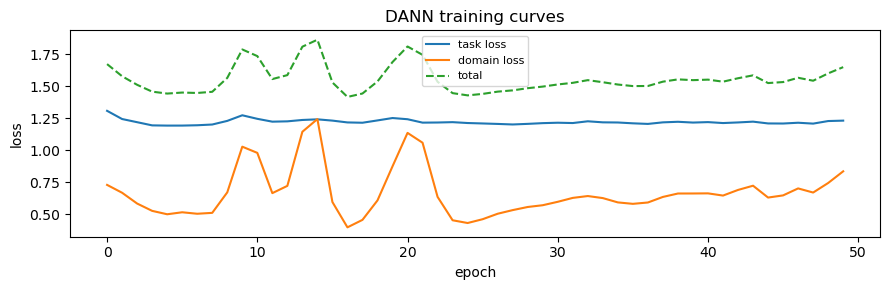

In [24]:
torch.manual_seed(42)
n_domains = 3 if behacom_available else 2

model = DANN(n_feat=len(EXTENDED), n_hidden=64, n_tasks=2, n_domains=n_domains)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

N_EPOCHS = 50
BATCH_SIZE = 256

# Build tensors — source has task labels; target has domain label only
ok_src = np.isfinite(Y_src).all(axis=1) & np.isfinite(X_src_z).all(axis=1)
Xt = torch.tensor(X_src_z[ok_src], dtype=torch.float32)
Yt = torch.tensor(Y_src[ok_src],   dtype=torch.float32)
Dt = torch.tensor(D_src[ok_src],   dtype=torch.long)

src_ds = TensorDataset(Xt, Yt, Dt)
src_loader = DataLoader(src_ds, batch_size=BATCH_SIZE, shuffle=True)

if behacom_available:
    ok_beh = np.isfinite(X_beh_z).all(axis=1)
    Xb = torch.tensor(X_beh_z[ok_beh], dtype=torch.float32)
    Db = torch.tensor(D_beh[ok_beh],   dtype=torch.long)
    beh_ds     = TensorDataset(Xb, Db)
    beh_loader = DataLoader(beh_ds, batch_size=BATCH_SIZE, shuffle=True)

print(f"Training DANN for {N_EPOCHS} epochs  |  source samples: {ok_src.sum()}")
history = {"task": [], "domain": [], "total": []}

for epoch in range(N_EPOCHS):
    lam = grl_lambda(epoch, N_EPOCHS)
    model.train()
    epoch_task = epoch_dom = 0.0
    n_batches = 0

    beh_iter = iter(beh_loader) if behacom_available else None

    for Xb_src, Yb_src, Db_src in src_loader:
        task_logits, dom_logits, _ = model(Xb_src, lam=lam)

        # task loss — binary CE per target, only where label is valid
        task_loss = torch.tensor(0.0)
        for j in range(2):
            valid = Yb_src[:, j].isfinite()
            if valid.sum() > 0:
                task_loss = task_loss + F.binary_cross_entropy_with_logits(
                    task_logits[j][valid], Yb_src[valid, j])

        # domain loss — source batch
        dom_loss = F.cross_entropy(dom_logits, Db_src)

        # if BEHACOM available, add a target-domain batch to domain loss
        if beh_iter is not None:
            try:
                Xb_tgt, Db_tgt = next(beh_iter)
            except StopIteration:
                beh_iter = iter(beh_loader)
                Xb_tgt, Db_tgt = next(beh_iter)
            _, dom_tgt, _ = model(Xb_tgt, lam=lam)
            dom_loss = dom_loss + F.cross_entropy(dom_tgt, Db_tgt)

        total_loss = task_loss + 0.5 * dom_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_task += task_loss.item()
        epoch_dom  += dom_loss.item()
        n_batches  += 1

    history["task"].append(epoch_task / n_batches)
    history["domain"].append(epoch_dom / n_batches)
    history["total"].append((epoch_task + 0.5 * epoch_dom) / n_batches)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS}  "
              f"task={history['task'][-1]:.4f}  "
              f"domain={history['domain'][-1]:.4f}  "
              f"λ={lam:.3f}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(history["task"],   label="task loss")
ax.plot(history["domain"], label="domain loss")
ax.plot(history["total"],  label="total", ls="--")
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
ax.set_title("DANN training curves"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## V.4 — Evaluation: DANN vs. no-adaptation baseline (LOSO on SWELL-KW)
Compares three pipelines on the same task (predict HR_rising / RMSSD_rising
on SWELL-KW under LOSO):
  - Raw features → RF (no adaptation, from Part II.3)
  - DANN features → logistic layer (CogLab+SWELL aligned)
  - DANN features → RF

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

model.eval()
subs_sw_uniq = sorted(df_sw["PP"].unique())

results_dann = {tgt: [] for tgt in ["HR_rising","RMSSD_rising"]}
results_base = {tgt: [] for tgt in ["HR_rising","RMSSD_rising"]}

# rebuild SWELL-KW in the EXTENDED schema (already done above as X_sw / Y_sw)
ok_sw = np.isfinite(X_sw).all(axis=1)
X_sw_z = apply_zscore(X_sw, mu_src, sd_src)

for held in subs_sw_uniq:
    tr_mask = (groups_sw != held) & ok_sw
    te_mask = (groups_sw == held) & ok_sw
    if tr_mask.sum() < 20 or te_mask.sum() < 5:
        continue

    # DANN features
    with torch.no_grad():
        _, _, feat_tr = model(torch.tensor(X_sw_z[tr_mask], dtype=torch.float32))
        _, _, feat_te = model(torch.tensor(X_sw_z[te_mask], dtype=torch.float32))
    F_tr = feat_tr.numpy(); F_te = feat_te.numpy()

    for j, tgt in enumerate(["HR_rising","RMSSD_rising"]):
        y_col = j  # HR_rising=0, RMSSD_rising=1
        y_tr  = Y_sw[tr_mask, y_col]
        y_te  = Y_sw[te_mask, y_col]
        v_tr  = np.isfinite(y_tr); v_te = np.isfinite(y_te)
        if v_tr.sum() < 10 or v_te.sum() < 3:
            continue

        # baseline: raw extended features → RF
        base_rf = RandomForestClassifier(200, min_samples_leaf=5,
                                          class_weight="balanced",
                                          random_state=0, n_jobs=-1)
        mu_b = X_sw_z[tr_mask][v_tr].mean(0); sd_b = X_sw_z[tr_mask][v_tr].std(0)+1e-9
        base_rf.fit((X_sw_z[tr_mask][v_tr]-mu_b)/sd_b, y_tr[v_tr])
        pred_b = base_rf.predict((X_sw_z[te_mask][v_te]-mu_b)/sd_b)
        results_base[tgt].append(accuracy_score(y_te[v_te], pred_b))

        # DANN: domain-invariant features → LR
        lr = LogisticRegression(C=1.0, max_iter=500, class_weight="balanced")
        lr.fit(F_tr[v_tr], y_tr[v_tr])
        pred_d = lr.predict(F_te[v_te])
        results_dann[tgt].append(accuracy_score(y_te[v_te], pred_d))

print(f"\n{'Target':14s} {'No-adapt (RF)':>14s} {'DANN+LR':>10s} {'Δ':>8s}  chance=0.50")
print("-"*52)
for tgt in ["HR_rising","RMSSD_rising"]:
    base = np.nanmean(results_base[tgt])
    dann = np.nanmean(results_dann[tgt])
    print(f"{tgt:14s} {base:14.3f} {dann:10.3f} {dann-base:+8.3f}")

print()
print("INTERPRETATION:")
print("  If DANN Δ > 0: domain alignment helped generalize across datasets.")
print("  If DANN Δ ≈ 0 or negative: features aren't transferable even with")
print("  alignment — the task-specific information doesn't exist in the 4")
print("  common features, or CogLab's contribution adds noise.")


Target          No-adapt (RF)    DANN+LR        Δ  chance=0.50
----------------------------------------------------
HR_rising               0.746      0.517   -0.229
RMSSD_rising            0.729      0.484   -0.245

INTERPRETATION:
  If DANN Δ > 0: domain alignment helped generalize across datasets.
  If DANN Δ ≈ 0 or negative: features aren't transferable even with
  alignment — the task-specific information doesn't exist in the 4
  common features, or CogLab's contribution adds noise.


## V.5 — Apply to BEHACOM: generate biosignal proxy per user

In [26]:
if behacom_available:
    model.eval()
    print("Generating physiologically-grounded proxy scores for BEHACOM users")
    print("="*70)

    behacom_proxies = []
    for uid in np.unique(U_beh):
        mask = (U_beh == uid) & np.isfinite(X_beh_z).all(axis=1)
        if mask.sum() == 0:
            continue
        with torch.no_grad():
            task_logits, _, feat = model(
                torch.tensor(X_beh_z[mask], dtype=torch.float32))
        hr_prob    = torch.sigmoid(task_logits[0]).numpy()
        rmssd_prob = torch.sigmoid(task_logits[1]).numpy()
        # CCA-style composite: mean of the two direction probabilities,
        # re-centered so 0.5 = neutral, positive = load rising
        composite = (hr_prob + rmssd_prob) / 2.0 - 0.5

        behacom_proxies.append({
            "user": uid,
            "n_windows": mask.sum(),
            "hr_rising_mean":    float(hr_prob.mean()),
            "rmssd_rising_mean": float(rmssd_prob.mean()),
            "composite_load":    float(composite.mean()),
        })

    df_proxy = pd.DataFrame(behacom_proxies)
    print(df_proxy.to_string(index=False))
    print()
    print("composite_load interpretation:")
    print("  >  0 : physiological arousal trending upward on average")
    print("  ≈  0 : neutral / balanced")
    print("  <  0 : physiological arousal trending downward")
    print()
    print("This is a SOFT auxiliary signal — confidence is limited by:")
    print("  1. Only 4 common features across all 3 datasets")
    print("  2. DANN validated on SWELL-KW but never on BEHACOM (no biosig GT)")
    print("  3. CogLab's passive-task contribution may add noise not signal")
    print()
    print("USE CASE: auxiliary supervision for GNN encoder training,")
    print("not ground-truth cognitive load for direct classification.")
else:
    print("BEHACOM not available at the expected path — skipping proxy generation.")
    print("If you have the dataset, set BEHACOM_DIR to its location and re-run.")

BEHACOM not available at the expected path — skipping proxy generation.
If you have the dataset, set BEHACOM_DIR to its location and re-run.


## V.6 — Summary: DANN outcome

In [27]:
print("="*70)
print("DANN — SUMMARY")
print("="*70)
print()
print("QUESTION: Can domain-adversarial alignment bridge the Cog Lab /")
print("SWELL-KW difference and produce a biosignal proxy for BEHACOM?")
print()
print("WHAT DANN ADDS vs. the earlier gate tests:")
print("  - Gate tests asked: does X predict Y in one dataset (no transfer)?")
print("  - DANN asks: can a shared representation predict Y across datasets?")
print("  - The Δ in V.4 above is the direct measure of what alignment buys.")
print()
print("KNOWN HARD LIMIT regardless of DANN performance:")
print("  CogLab's passive task has no app-switching. The SnAppChange /")
print("  changes_between_apps dimension — which was the single strongest")
print("  behavioral correlate of HR in SWELL-KW (r=-0.40) — cannot be")
print("  learned by CogLab's contribution to the source domain at all.")
print("  DANN can only align what both source datasets share.")
print()
print("LITERATURE anchor:")
print("  Ganin & Lempitsky (2015), JMLR — the original DANN paper.")
print("  Ott et al. (2022) — domain adaptation for time-series covariate")
print("  shift, directly addresses biosignal / wearable cross-dataset transfer.")
print("  CORAL (Sun & Saenko 2016) — a simpler 1-step covariance alignment")
print("  baseline worth comparing against: if CORAL already achieves the")
print("  same Δ as DANN, the GRL adversarial machinery isn't adding value.")

DANN — SUMMARY

QUESTION: Can domain-adversarial alignment bridge the Cog Lab /
SWELL-KW difference and produce a biosignal proxy for BEHACOM?

WHAT DANN ADDS vs. the earlier gate tests:
  - Gate tests asked: does X predict Y in one dataset (no transfer)?
  - DANN asks: can a shared representation predict Y across datasets?
  - The Δ in V.4 above is the direct measure of what alignment buys.

KNOWN HARD LIMIT regardless of DANN performance:
  CogLab's passive task has no app-switching. The SnAppChange /
  changes_between_apps dimension — which was the single strongest
  behavioral correlate of HR in SWELL-KW (r=-0.40) — cannot be
  learned by CogLab's contribution to the source domain at all.
  DANN can only align what both source datasets share.

LITERATURE anchor:
  Ganin & Lempitsky (2015), JMLR — the original DANN paper.
  Ott et al. (2022) — domain adaptation for time-series covariate
  shift, directly addresses biosignal / wearable cross-dataset transfer.
  CORAL (Sun & Saenko 20